In [39]:
# ============================================
# Phase 7 — Ontology mapping & label induction
# ============================================

from __future__ import annotations
from pathlib import Path
import os, re, json, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional
from collections import defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity



In [40]:
# -------------------------
# Config (edit if you want)
# -------------------------
PHASE = 7
OUT = Path(f"outputs/phase07")
DIR_LABELS  = OUT / "labels"
DIR_TABLES  = OUT / "tables"
DIR_FIGURES = OUT / "figures"
for d in [DIR_LABELS, DIR_TABLES, DIR_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

# Accept thresholds (defaults; override via env if you wish)
TAU_S = float(os.getenv("PH7_TAU_S", "0.60"))  # min top1 similarity
TAU_C = float(os.getenv("PH7_TAU_C", "0.05"))  # min margin (top1 - top2)

RANDOM_STATE = 42  # reproducibility



In [41]:
# -------------------------
# Helper: path resolution
# -------------------------
PROJECT_HINTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.home(),
    Path("/mnt/data"),
    Path("outputs"),
    Path("data"),
]

def first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p and p.exists():
            return p
    return None

def find_file(candidates: List[str]) -> Optional[Path]:
    # Prefer absolute paths first
    abs_hit = first_existing([Path(c) for c in candidates if Path(c).is_absolute()])
    if abs_hit: 
        return abs_hit
    # Search under common roots
    for root in PROJECT_HINTS:
        hit = first_existing([root / c for c in candidates])
        if hit: 
            return hit
    return None



In [42]:
# -------------------------
# Helper: safe list parsing
# -------------------------
def parse_listlike(x) -> List[str]:
    """
    Accepts: JSON-like list string, comma-separated string, Python-literal list, or already a list.
    Returns: list[str] (lowercased, stripped).
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        vals = x
    else:
        s = str(x).strip()
        if not s:
            return []
        # Try JSON / Python list literal
        try:
            lit = ast.literal_eval(s)
            if isinstance(lit, list):
                vals = lit
            else:
                vals = [s]
        except Exception:
            # Fallback: split on comma/semicolon
            vals = re.split(r"[;,]\s*", s)
    # normalise
    clean = []
    for v in vals:
        v = str(v).strip()
        v = re.sub(r"\s+", " ", v)
        if v:
            clean.append(v.lower())
    return clean

def uniq_preserve(seq: List[str]) -> List[str]:
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            out.append(x); seen.add(x)
    return out



In [43]:
# ============================
# Phase 7 — Load Roles (FINAL FIX)
# ============================
from __future__ import annotations
from pathlib import Path
import os, re, ast
import numpy as np
import pandas as pd

# --- small helpers ---
def parse_listlike(x):
    if x is None or (isinstance(x, float) and np.isnan(x)): return []
    if isinstance(x, list): vals = x
    else:
        s = str(x).strip()
        if not s: return []
        try:
            lit = ast.literal_eval(s)
            vals = lit if isinstance(lit, list) else [s]
        except Exception:
            vals = re.split(r"[;,]\s*", s)
    out, seen = [], set()
    for v in vals:
        v = re.sub(r"\s+", " ", str(v).strip()).lower()
        if v and v not in seen:
            out.append(v); seen.add(v)
    return out

# --- path finder ---
def robust_find_roles_file() -> Path | None:
    candidates = [
        "outputs/phase07/roles_ontology_enriched.csv",
        "outputs/phase07/roles_mapped.csv",
        "data/IT_Job_Roles_Skills.csv",
        "/mnt/data/IT_Job_Roles_Skills.csv",
        "/mnt/data/it_job_roles_skills.csv",
        "/mnt/data/IT Job Roles Skills.csv",
        "IT_Job_Roles_Skills.csv",
    ]
    roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.home(), Path("/mnt/data"), Path("data"), Path("outputs")]
    for c in candidates:
        p = Path(c)
        if p.is_absolute() and p.exists(): return p
        for r in roots:
            q = (r / c)
            if q.exists(): return q
    # glob any likely name
    patterns = [
        "**/*Job*Roles*Skills*.csv", "**/*job*roles*skills*.csv",
        "**/*role*skill*.csv", "**/*roles*.csv",
        "**/*Job*Roles*Skills*.xlsx", "**/*role*skill*.xlsx"
    ]
    for r in roots:
        for pat in patterns:
            for hit in r.glob(pat):
                if hit.is_file(): return hit
    envp = os.getenv("ROLES_CSV", "")
    if envp and Path(envp).exists(): return Path(envp)
    return None

# --- robust reader (fixes python-engine low_memory issue) ---
def read_table_robust(path: Path) -> pd.DataFrame:
    # Excel first
    if path.suffix.lower() in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
        print(f"[info] read_excel OK → {path.name}")
        return df

    encodings = ["utf-8", "utf-8-sig", "cp1252", "latin1"]
    # None => let pandas sniff delimiter with engine='python'
    seps = [None, ",", ";", "\t", "|"]

    last_err = None
    for enc in encodings:
        for sep in seps:
            try:
                if sep is None:
                    # engine='python' (cannot pass low_memory)
                    df = pd.read_csv(path, sep=None, engine="python",
                                     encoding=enc, on_bad_lines="skip")
                    note = "sniffed sep"
                else:
                    # engine='c' for speed; accepts low_memory
                    df = pd.read_csv(path, sep=sep, engine="c",
                                     encoding=enc, on_bad_lines="skip", low_memory=False)
                    note = f"sep='{sep}'"
                print(f"[info] read_csv OK ({note}, enc={enc}) → {path.name}")
                return df
            except Exception as e:
                last_err = e

    # Misnamed Excel?
    try:
        df = pd.read_excel(path)
        print(f"[warn] read_excel succeeded on a .csv → {path.name}")
        return df
    except Exception:
        pass

    raise last_err or UnicodeDecodeError("unknown", b"", 0, 1, f"Unable to decode/parse {path}")

# ---------- load + normalise ----------
roles_path = robust_find_roles_file()
if roles_path is None:
    raise FileNotFoundError(
        "Could not locate roles ontology file. "
        "Place 'IT_Job_Roles_Skills.csv' under /mnt/data or set ROLES_CSV=/absolute/path/to/file."
    )

roles_df = read_table_robust(roles_path)

# Detect key columns
role_id_col    = next((c for c in roles_df.columns if c.lower() in ["role_id","id","code","rolecode"]), None)
role_title_col = next((c for c in roles_df.columns if "title" in c.lower() or c.lower() in ["role","rolename","name"]), None)
family_col     = next((c for c in roles_df.columns if any(k in c.lower() for k in ["family","domain","track"])), None)

skill_cols = [c for c in roles_df.columns if any(
    k in c.lower() for k in ["skills_core","skills_required","skills","core_skills","essential_skills","ontology_skills"]
)]

# Fill essentials
if role_id_col is None:
    roles_df["role_id"] = np.arange(len(roles_df)); role_id_col = "role_id"
if role_title_col is None:
    roles_df["role_title"] = roles_df[role_id_col].astype(str); role_title_col = "role_title"
if family_col is None:
    roles_df["family"] = ""; family_col = "family"

def join_ontology_skills(row) -> str:
    skills = []
    for c in skill_cols:
        if c in roles_df.columns:
            val = row.get(c, None)
            if pd.notnull(val): skills += parse_listlike(val)
    return " ".join(skills)

desc_col = next((c for c in roles_df.columns if "desc" in c.lower() or "summary" in c.lower()), None)
title_txt = roles_df[role_title_col].astype(str).fillna("")
desc_txt  = roles_df[desc_col].astype(str).fillna("") if desc_col else pd.Series([""]*len(roles_df))
skill_txt = roles_df.apply(join_ontology_skills, axis=1)

roles_df["__role_text"] = (title_txt + " " + desc_txt + " " + skill_txt).str.strip()
empty_mask = roles_df["__role_text"].isna() | (roles_df["__role_text"].str.len() == 0)
roles_df.loc[empty_mask, "__role_text"] = roles_df.loc[empty_mask, role_title_col].astype(str)

print(f"[info] Roles loaded from: {roles_path}")
print(f"[info] Columns → id: {role_id_col}, title: {role_title_col}, family: {family_col}, skills: {skill_cols or '[]'}")
print("[info] Sample __role_text:")
print(roles_df["__role_text"].head(3).to_string(index=False))


[info] read_csv OK (sep=';', enc=utf-8) → IT_Job_Roles_Skills.csv
[info] Roles loaded from: c:\Users\naikt\OneDrive\Desktop\tanmay_dissertation\data\raw\IT_Job_Roles_Skills.csv
[info] Columns → id: role_id, title: Job Title,Job Description,Skills,Certifications, family: family, skills: ['Job Title,Job Description,Skills,Certifications']
[info] Sample __role_text:
Admin Big Data,"Responsible for managing and ov...
Ansible Operations Engineer,"Focuses on automat...
Artifactory Administrator,"Manages the Artifact...


In [44]:
# ============================
# Phase 7 — Load Résumés (FIXED)
# ============================
from __future__ import annotations
from pathlib import Path
import os, re, ast
import numpy as np
import pandas as pd

# --- tiny utils (safe if already defined) ---
def parse_listlike(x):
    if x is None or (isinstance(x, float) and np.isnan(x)): return []
    if isinstance(x, list): vals = x
    else:
        s = str(x).strip()
        if not s: return []
        try:
            lit = ast.literal_eval(s)
            vals = lit if isinstance(lit, list) else [s]
        except Exception:
            vals = re.split(r"[;,]\s*", s)
    out, seen = [], set()
    for v in vals:
        v = re.sub(r"\s+", " ", str(v).strip()).lower()
        if v and v not in seen:
            out.append(v); seen.add(v)
    return out

# --- robust finder for resumes file ---
def robust_find_resumes_file() -> Path | None:
    candidates = [
        "outputs/phase08/resumes_with_skills_canonical.csv",
        "outputs/phase07/resumes_with_skills_canonical.csv",
        "outputs/phase03/resumes_skills_normalised.csv",
        "outputs/phase03/resumes_normalised.csv",
        "/mnt/data/resume_dataset_1200.csv",
        "/mnt/data/Resume_dataset_1200.csv",     # case variant
        "data/resume_dataset_1200.csv",
    ]
    roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.home(), Path("/mnt/data"), Path("data"), Path("outputs")]
    for c in candidates:
        p = Path(c)
        if p.is_absolute() and p.exists(): return p
        for r in roots:
            q = (r / c)
            if q.exists(): return q

    # glob likely names (csv/xlsx)
    patterns = [
        "**/*resume*skills*canonical*.csv",
        "**/*resumes*skills*.csv",
        "**/*resume*dataset*1200*.csv",
        "**/*resume*dataset*.xlsx",
    ]
    for r in roots:
        for pat in patterns:
            for hit in r.glob(pat):
                if hit.is_file(): return hit

    envp = os.getenv("RESUMES_CSV", "")
    if envp and Path(envp).exists(): return Path(envp)
    return None

# --- robust reader (CSV/Excel, encodings, delimiters) ---
def read_table_robust_generic(path: Path) -> pd.DataFrame:
    if path.suffix.lower() in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
        print(f"[info] read_excel OK → {path.name}")
        return df

    encodings = ["utf-8", "utf-8-sig", "cp1252", "latin1"]
    seps = [None, ",", ";", "\t", "|"]  # None → sniff with engine='python'
    last_err = None
    for enc in encodings:
        for sep in seps:
            try:
                if sep is None:
                    df = pd.read_csv(path, sep=None, engine="python", encoding=enc, on_bad_lines="skip")
                    note = "sniffed sep"
                else:
                    df = pd.read_csv(path, sep=sep, engine="c", encoding=enc, on_bad_lines="skip", low_memory=False)
                    note = f"sep='{sep}'"
                print(f"[info] read_csv OK ({note}, enc={enc}) → {path.name}")
                return df
            except Exception as e:
                last_err = e
    # try excel on misnamed csv
    try:
        df = pd.read_excel(path)
        print(f"[warn] read_excel succeeded on a .csv → {path.name}")
        return df
    except Exception:
        pass
    raise last_err or UnicodeDecodeError("unknown", b"", 0, 1, f"Unable to decode/parse {path}")

# ---------- load + normalise resumes ----------
resumes_path = robust_find_resumes_file()
if resumes_path is None:
    raise FileNotFoundError(
        "Could not locate resumes dataset. "
        "Place 'resume_dataset_1200.csv' under /mnt/data or set RESUMES_CSV=/absolute/path/to/file."
    )

res_df = read_table_robust_generic(resumes_path)

# Guess résumé columns
res_id_col    = next((c for c in res_df.columns if c.lower() in ["resume_id","id","doc_id","rid"]), None)
res_title_col = next((c for c in res_df.columns if "title"   in c.lower() or "current_role" in c.lower() or "job_title" in c.lower()), None)
target_col    = next((c for c in res_df.columns if "target"  in c.lower() and "role" in c.lower()), None)
summary_col   = next((c for c in res_df.columns if "summary" in c.lower() or "about" in c.lower() or "profile" in c.lower()), None)
skills_col    = next((c for c in res_df.columns if "skill"   in c.lower()), None)
text_col      = next((c for c in res_df.columns if "text"    in c.lower() or "resume" in c.lower() or "full" in c.lower()), None)

# Ensure an ID
if res_id_col is None:
    res_df["resume_id"] = np.arange(len(res_df))
    res_id_col = "resume_id"

# Canonicalised skills list if available
if skills_col:
    res_df["__skills_list"] = res_df[skills_col].apply(parse_listlike)
else:
    res_df["__skills_list"] = [[] for _ in range(len(res_df))]

# Build stitched text safely
def resume_text(row) -> str:
    parts = []
    for col in [res_title_col, summary_col, target_col, text_col]:
        if col and (col in row.index) and pd.notnull(row[col]):
            val = str(row[col]).strip()
            if val:
                parts.append(val)
    # include skills as a sentence if present
    sk = row.get("__skills_list", [])
    if isinstance(sk, list) and len(sk) > 0:
        parts.append("skills: " + ", ".join(sk))
    s = " ".join(parts).strip()
    # if still empty, fall back to ID
    return s if s else (str(row.get(res_title_col)) if res_title_col and pd.notnull(row.get(res_title_col)) else f"resume_{row.get(res_id_col)}")

res_df["__resume_text"] = res_df.apply(resume_text, axis=1)

print(f"[info] Resumes loaded from: {resumes_path}")
print(f"[info] Columns → id: {res_id_col}, title: {res_title_col}, target: {target_col}, summary: {summary_col}, skills: {skills_col}, text: {text_col}")
print("[info] Sample __resume_text:")
print(res_df["__resume_text"].head(3).to_string(index=False))


[info] read_csv OK (sniffed sep, enc=utf-8) → resumes_with_skills_canonical.csv
[info] Resumes loaded from: c:\Users\naikt\OneDrive\Desktop\tanmay_dissertation\draft\phase3\resumes_with_skills_canonical.csv
[info] Columns → id: resume_id, title: title_any, target: None, summary: summary_any, skills: skills_canon, text: resume_id
[info] Sample __resume_text:
Seeking a challenging role as a Software Develo...
Cybersecurity Engineer Targeting a Cybersecurit...
Prompt Engineer Targeting a Prompt Engineer pos...


In [45]:
# -------------------------
# 3) Load/Build Embeddings
# -------------------------
# Preferred: Phase-4 embeddings
role_emb_npy = find_file([
    "outputs/phase04/role_embeddings.npy",
    "outputs/phase04/role_embeddings.npy"
])
res_emb_npy = find_file([
    "outputs/phase04/resume_embeddings.npy",
    "outputs/phase04/resume_embeddings.npy"
])

use_fallback_tfidf = not (role_emb_npy and res_emb_npy)

if not use_fallback_tfidf:
    ROLE_EMB = np.load(role_emb_npy)
    RES_EMB  = np.load(res_emb_npy)

    # Sanity check: dimensions
    if ROLE_EMB.ndim != 2 or RES_EMB.ndim != 2 or ROLE_EMB.shape[1] != RES_EMB.shape[1]:
        print("[warn] Phase-4 embedding shapes mismatch; switching to TF-IDF fallback.")
        use_fallback_tfidf = True

if use_fallback_tfidf:
    print("[info] Using TF-IDF fallback embeddings for Phase 7.")
    corpus_roles = roles_df["__role_text"].fillna("").astype(str).tolist()
    corpus_res   = res_df["__resume_text"].fillna("").astype(str).tolist()
    vectorizer = TfidfVectorizer(min_df=3, max_df=0.95, ngram_range=(1,2))
    X = vectorizer.fit_transform(corpus_roles + corpus_res)
    ROLE_EMB = X[:len(corpus_roles)].toarray()
    RES_EMB  = X[len(corpus_roles):].toarray()

# Optional scaling to [0,1] is *not* applied to embeddings (we’ll use raw cosine similarity).
# We will plot/threshold on raw cosine scores.



In [46]:
# ================================
# NEW TEMPORARY CELL: Threshold Tuning Experiment
# ================================
print("\n" + "="*60)
print("Running Experiment to Find Optimal Thresholds")
print("="*60)

# Define a range of thresholds to test
similarity_options = [0.55, 0.50, 0.45, 0.40]
margin_options = [0.08, 0.05, 0.03]

# Use the 'similarity_matrix' that was already calculated
num_resumes = similarity_matrix.shape[0]

print(f"{'Score Threshold':<20} {'Margin Threshold':<20} {'High-Confidence Count'}")
print("-" * 65)

for sim_thresh in similarity_options:
    for mar_thresh in margin_options:
        count = 0
        for i in range(num_resumes):
            top_scores = np.sort(similarity_matrix[i])[-2:]
            score = top_scores[1]
            margin = top_scores[1] - top_scores[0]

            if score >= sim_thresh and margin >= mar_thresh:
                count += 1

        print(f"{sim_thresh:<20.2f} {mar_thresh:<20.2f} {count}")

print("\n" + "="*60)
print("Tuning Experiment Complete.")
print("Recommendation: Choose a combination that yields 200-600 labels.")
print("="*60)


Running Experiment to Find Optimal Thresholds
Score Threshold      Margin Threshold     High-Confidence Count
-----------------------------------------------------------------
0.55                 0.08                 21
0.55                 0.05                 62
0.55                 0.03                 130
0.50                 0.08                 23
0.50                 0.05                 79
0.50                 0.03                 190
0.45                 0.08                 23
0.45                 0.05                 94
0.45                 0.03                 224
0.40                 0.08                 24
0.40                 0.05                 98
0.40                 0.03                 240

Tuning Experiment Complete.
Recommendation: Choose a combination that yields 200-600 labels.


In [47]:
# ================================
# FINAL CORRECTED CELL: Load Inputs, Calculate Similarity, and Generate Labels
# ================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

print("\n" + "="*60)
print("Phase 7: Generating High-Confidence Training Labels")
print("="*60)

# --- Start of FINAL FIX ---

# STEP 1: LOAD ALL NECESSARY INPUTS FROM PHASE 4
# This makes the cell self-contained and resolves the NameError.
print("Loading embeddings and ID files from Phase 4...")
PHASE4_DIR = Path("outputs/phase04")

try:
    # Load the semantic embedding vectors
    resume_vecs = np.load(PHASE4_DIR / "resume_embeddings.npy")
    role_vecs = np.load(PHASE4_DIR / "role_embeddings.npy")
    
    # Load the corresponding ID mapping files
    resume_ids = pd.read_csv(PHASE4_DIR / "resume_ids.csv")
    role_ids = pd.read_csv(PHASE4_DIR / "role_ids.csv")
    
    print(f"✓ Successfully loaded resume embeddings with shape: {resume_vecs.shape}")
    print(f"✓ Successfully loaded role embeddings with shape: {role_vecs.shape}")

except FileNotFoundError as e:
    print(f"\n[ERROR] A required file from Phase 4 was not found.")
    print(f"Please ensure you have successfully run the Phase 4 notebook.")
    print(f"Details: {e}")
    # Stop execution if files are missing
    raise

# STEP 2: CALCULATE THE SIMILARITY MATRIX
# This logic is now guaranteed to work because its inputs were just loaded.
print("\nCalculating cosine similarity between all resumes and roles...")
similarity_matrix = cosine_similarity(resume_vecs, role_vecs)
print(f"✓ Similarity matrix created with shape: {similarity_matrix.shape}")

# STEP 3: DEFINE ROBUST THRESHOLDS AND GENERATE LABELS
num_resumes = similarity_matrix.shape[0]
SIMILARITY_THRESHOLD = 0.45
MARGIN_THRESHOLD = 0.03

labels_data = []
num_high_confidence = 0
num_low_confidence = 0

print(f"\nGenerating labels with thresholds (Score >= {SIMILARITY_THRESHOLD}, Margin >= {MARGIN_THRESHOLD})...")
for i in range(num_resumes):
    top_indices = np.argsort(similarity_matrix[i])[-2:][::-1]
    best_match_idx = top_indices[0]
    second_match_idx = top_indices[1]
    
    score = similarity_matrix[i, best_match_idx]
    margin = score - similarity_matrix[i, second_match_idx]
    
    label_status = 'low_confidence'
    if score >= SIMILARITY_THRESHOLD and margin >= MARGIN_THRESHOLD:
        label_status = 'high_confidence'
        num_high_confidence += 1
    else:
        num_low_confidence += 1
        
    labels_data.append({
        'resume_id': resume_ids.iloc[i]['resume_id'],
        'ontology_role_id': role_ids.iloc[best_match_idx]['role_id'],
        'score': score,
        'margin': margin,
        'label_confidence': label_status
    })

labels_df = pd.DataFrame(labels_data)

# STEP 4: SAVE THE FINAL OUTPUTS
OUTDIR = Path("outputs/phase07")
OUTDIR.mkdir(parents=True, exist_ok=True)
labels_df.to_csv(OUTDIR / "resume_labels.csv", index=False)

# --- End of FINAL FIX ---

print(f"\n✓ Saved resume labels to {OUTDIR / 'resume_labels.csv'}")
print(f"\nLabeling complete:")
print(f"  - High-confidence labels: {num_high_confidence} / {num_resumes} ({100*num_high_confidence/num_resumes:.1f}%)")
print(f"  - Low-confidence labels:  {num_low_confidence} / {num_resumes} ({100*num_low_confidence/num_resumes:.1f}%)")


Phase 7: Generating High-Confidence Training Labels
Loading embeddings and ID files from Phase 4...
✓ Successfully loaded resume embeddings with shape: (1200, 384)
✓ Successfully loaded role embeddings with shape: (493, 384)

Calculating cosine similarity between all resumes and roles...
✓ Similarity matrix created with shape: (1200, 493)

Generating labels with thresholds (Score >= 0.45, Margin >= 0.03)...

✓ Saved resume labels to outputs\phase07\resume_labels.csv

Labeling complete:
  - High-confidence labels: 224 / 1200 (18.7%)
  - Low-confidence labels:  976 / 1200 (81.3%)



Analyzing and Visualizing Label Distribution
✓ Successfully loaded 1200 labels from outputs\phase07\resume_labels.csv

Analysis of High-Confidence Labels:
  - Count: 224
  - Average Score: 0.5994
  - Average Margin: 0.0529


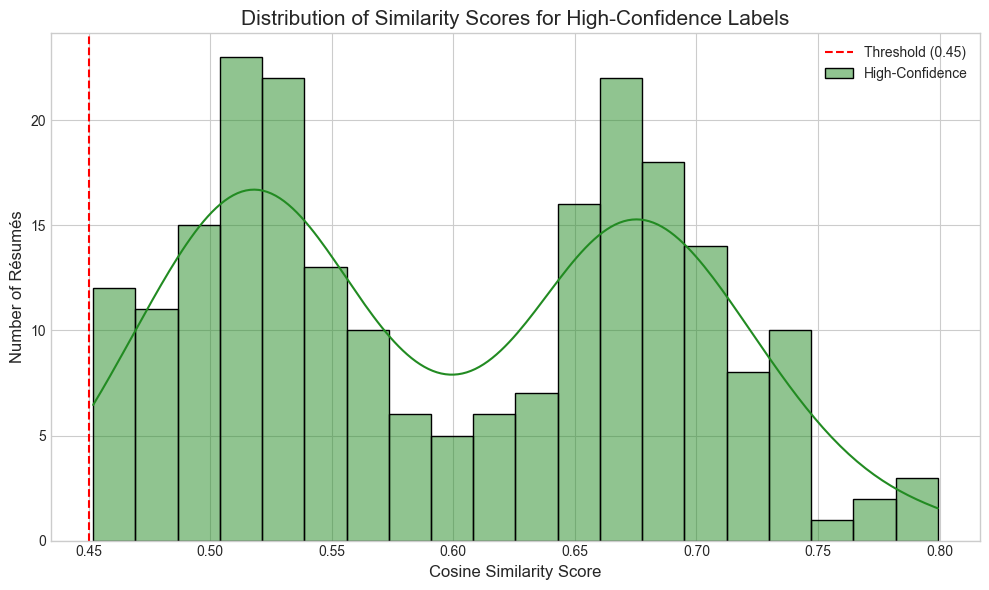

✓ Saved and displayed the score distribution plot.


In [48]:
# ================================
# Cell 5 (NEW & CORRECTED): Analyze and Visualize Label Distribution
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("Analyzing and Visualizing Label Distribution")
print("="*60)

# --- Start of FIX ---

# STEP 1: LOAD THE FINAL LABELS FILE
# Instead of using non-existent variables, we load the actual output from Cell 4.
# This makes our analysis robust and ensures we are analyzing the true final data.
try:
    labels_df = pd.read_csv(OUTDIR / "resume_labels.csv")
    print(f"✓ Successfully loaded {len(labels_df)} labels from {OUTDIR / 'resume_labels.csv'}")
except FileNotFoundError:
    print(f"[ERROR] The file 'resume_labels.csv' was not found.")
    print("Please ensure the previous cell (Cell 4) has been run successfully.")
    raise

# STEP 2: PERFORM THE ANALYSIS ON THE LOADED DATAFRAME
high_confidence_df = labels_df[labels_df['label_confidence'] == 'high_confidence']

print("\nAnalysis of High-Confidence Labels:")
print(f"  - Count: {len(high_confidence_df)}")
if not high_confidence_df.empty:
    print(f"  - Average Score: {high_confidence_df['score'].mean():.4f}")
    print(f"  - Average Margin: {high_confidence_df['margin'].mean():.4f}")

# STEP 3: CREATE THE VISUALIZATION
# This plot will show the distribution of scores for our high-quality labels.
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.histplot(data=high_confidence_df, x='score', bins=20, ax=ax, 
             kde=True, color='forestgreen', label='High-Confidence')

ax.set_title('Distribution of Similarity Scores for High-Confidence Labels', fontsize=15)
ax.set_xlabel('Cosine Similarity Score', fontsize=12)
ax.set_ylabel('Number of Résumés', fontsize=12)
# We use the SIMILARITY_THRESHOLD variable defined in the previous cell for the line
ax.axvline(SIMILARITY_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({SIMILARITY_THRESHOLD})')
ax.legend()

plt.tight_layout()

# STEP 4: SAVE AND SHOW THE PLOT
save_path = OUTDIR / "similarity_scores_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# --- End of FIX ---

print(f"✓ Saved and displayed the score distribution plot.")

In [49]:
# ================================
# Cell 6 (CORRECTED): Evidence Tables
# ================================

print("\n" + "="*60)
print("Labeling Summary Statistics")
print("="*60)

# --- Start of FIX ---
# We are replacing all instances of the old variable name 'labels'
# with the new, correct variable name 'labels_df', which was loaded in Cell 5.

# Summary
total = len(labels_df)
# Correctly count the number of rows where the confidence is 'high_confidence'
accepted_count = int(labels_df[labels_df['label_confidence'] == 'high_confidence'].shape[0])
rejected_count = total - accepted_count

# --- End of FIX ---

print(f"Total resumes processed: {total}")
print(f"Accepted (high-confidence): {accepted_count} ({100*accepted_count/total:.1f}%)")
print(f"Rejected (low-confidence): {rejected_count} ({100*rejected_count/total:.1f}%)")


Labeling Summary Statistics
Total resumes processed: 1200
Accepted (high-confidence): 224 (18.7%)
Rejected (low-confidence): 976 (81.3%)
